# CardioInsight: Heart Disease Prediction & Clinical Risk Analysis

## **Project Overview**
**CardioInsight** is an end-to-end Machine Learning project developed as part of the NTI training program. The core objective of this system is to predict the presence of heart disease in individuals based on a comprehensive set of demographic, lifestyle, and clinical health indicators.

### **Key Project Objectives:**
1. **Exploratory Data Analysis (EDA):** Perform deep statistical inspection, handle missing data, engineer health-related features (such as BMI and Pulse Pressure), and uncover hidden correlations between clinical parameters and heart disease.
2. **Machine Learning Pipeline:** Implement robust data preprocessing (Encoding, Scaling, and Train-Test Stratification) and train a diverse suite of 9 classification algorithms ranging from linear models to advanced tree-based ensembles and neural network-backed classifiers.
3. **Model Evaluation & Comparison:** Rigorously evaluate models using multi-metric performance indicators (Accuracy, Precision, Recall, F1-Score, and ROC-AUC) to identify the most reliable diagnostic tool.
4. **Clinical Risk Interpretation:** Analyze model predictions to highlight primary risk factors (such as Hypertension, Cholesterol levels, and Age) to assist in proactive healthcare decision-making.

---
* **Team :** Ammar Yasser, Abdallah Essam, Youssef Abdallah, Nada Mohamed, Bassant Ibrahim
* **Dataset:** Heart Disease Dataset (50,000 records)

# Data Preprocessing & EDA

## 1. IMPORT REQUIRED LIBRARIES

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC, LinearSVC

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)

from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import warnings

# Suppress warning messages to keep the output clean and professional
warnings.filterwarnings('ignore')

## 2. LOAD DATASET

In [2]:
data_path = r'D:\AI\NTI\CardioInsight🫀        data_synthetic_92%\Data\origin\synthetic_heart_disease_dataset.csv'

df = pd.read_csv(data_path)

## 3. INITIAL DATA INSPECTION

In [3]:
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [4]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  str    
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  str    
 6   Alcohol_Intake         29891 non-null  str    
 7   Physical_Activity      50000 non-null  str    
 8   Diet                   50000 non-null  str    
 9   Stress_Level           50000 non-null  str    
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Systolic_BP  

In [5]:

print(f"Shape of dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Shape of dataset: 50000 rows, 21 columns


In [6]:

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [7]:

missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_columns)

Columns with missing values:
Alcohol_Intake    20109
dtype: int64


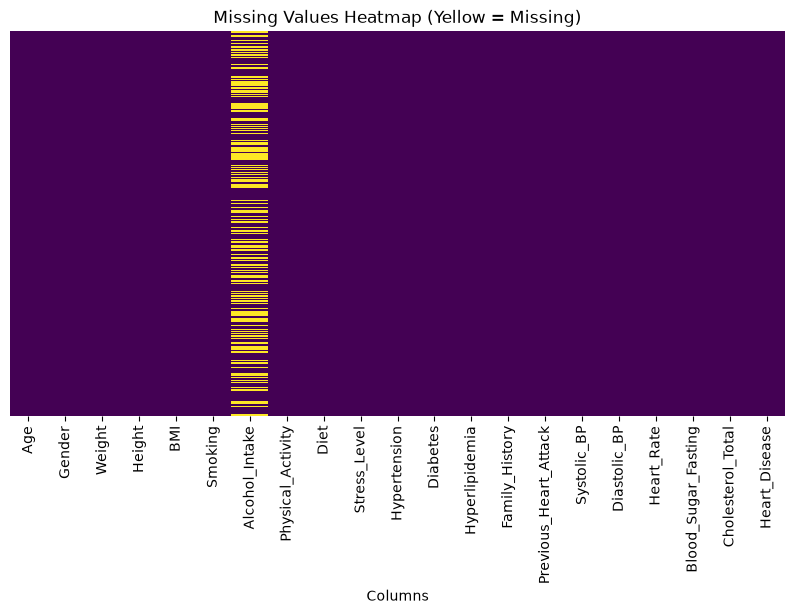

In [8]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False,
)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.xlabel('Columns')
plt.show()

**Missing Values Analysis**

* **Complete Columns:** Nearly all columns (such as Age, Gender, BMI, Smoking, Blood Pressure features, and the target variable) are completely populated with zero missing values (represented by the uniform dark background).
* **Missing Feature:** The **Alcohol_Intent / Alcohol_Intake** column is the sole feature containing missing data, clearly indicated by the scattered yellow horizontal lines representing null entries across the dataset rows.

## 4.Dataset Feature Analysis

In [ ]:
# Dataset Feature Analysis
# Comprehensive Feature Analysis (Unique Values Count & Range per Column)


print(f"{'Feature':<25} | {'Unique Count':<12} | {'Values / Range'}")
print("-" * 65)

for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 10:
        vals = str(df[col].unique().tolist())
    else:
        vals = f"Range: [{df[col].min()} to {df[col].max()}]"
    print(f"{col:<25} | {n_unique:<12} | {vals}")

Feature                   | Unique Count | Values / Range
-----------------------------------------------------------------
Age                       | 50           | Range: [30 to 79]
Gender                    | 2            | ['Male', 'Female']
Weight                    | 70           | Range: [50 to 119]
Height                    | 50           | Range: [150 to 199]
BMI                       | 221          | Range: [18.0 to 40.0]
Smoking                   | 3            | ['Never', 'Current', 'Former']
Alcohol_Intake            | 3            | [nan, 'Low', 'Moderate', 'High']
Physical_Activity         | 3            | ['Sedentary', 'Active', 'Moderate']
Diet                      | 3            | ['Healthy', 'Average', 'Unhealthy']
Stress_Level              | 3            | ['Medium', 'High', 'Low']
Hypertension              | 2            | [0, 1]
Diabetes                  | 2            | [0, 1]
Hyperlipidemia            | 2            | [1, 0]
Family_History            | 2       

 Numerical Features Statistics

In [ ]:

print("=== Numerical Features Statistics ===")
display(df.describe(include=[np.number]).round(2))


=== Numerical Features Statistics ===


,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,54.46,84.55,174.46,28.98,0.30,0.2,0.25,0.40,0.1,139.30,89.53,84.45,124.49,224.56,0.46
std,14.44,20.21,14.42,6.37,0.46,0.4,0.43,0.49,0.3,23.08,17.26,14.49,31.69,43.16,0.50
min,30.00,50.00,150.00,18.00,0.00,0.0,0.00,0.00,0.0,100.00,60.00,60.00,70.00,150.00,0.00
25%,42.00,67.00,162.00,23.50,0.00,0.0,0.00,0.00,0.0,119.00,75.00,72.00,97.00,187.00,0.00
50%,54.00,85.00,174.00,29.00,0.00,0.0,0.00,0.00,0.0,139.00,90.00,85.00,125.00,225.00,0.00
75%,67.00,102.00,187.00,34.50,1.00,0.0,1.00,1.00,0.0,159.00,104.00,97.00,152.00,262.00,1.00
max,79.00,119.00,199.00,40.00,1.00,1.0,1.00,1.00,1.0,179.00,119.00,109.00,179.00,299.00,1.00


 Categorical Features Statistics

In [ ]:

print("=== Categorical Features Statistics ===")
display(df.describe(include=['object', 'category']))

=== Categorical Features Statistics ===


,Gender,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level
count,50000,50000,29891,50000,50000,50000
unique,2,3,3,3,3,3
top,Female,Never,Low,Moderate,Average,Medium
freq,25110,30160,14913,24976,25169,20133


In [12]:

print(pd.DataFrame({
    'Count': df['Heart_Disease'].value_counts(),
    'Percentage': (df['Heart_Disease'].value_counts(normalize=True) * 100).round(2).astype(str) + '%'
}))

               Count Percentage
Heart_Disease                  
0              26827     53.65%
1              23173     46.35%


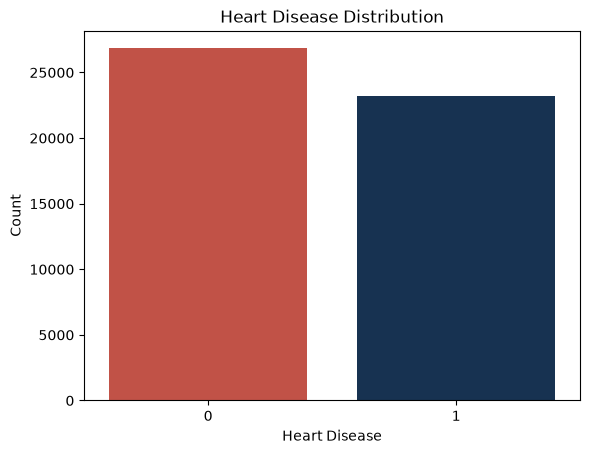

In [13]:

sns.countplot(x='Heart_Disease', data=df , palette=["#D54133", "#0E315A"])

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')

plt.show()


**Target Variable Distribution**

* **Class Balance:** The dataset shows a remarkably well-balanced distribution between the two classes:
  * **Class 0 (No Heart Disease):** ~27,000 instances (approx. 54%).
  * **Class 1 (Heart Disease):** ~23,000 instances (approx. 46%).
* **Machine Learning Implication:** Because the classes are nearly balanced, standard classification models can be trained directly without requiring heavy resampling techniques (such as SMOTE or class re-weighting) to handle class imbalance.

In [14]:

df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna('None')

In [15]:

df = df[df['Systolic_BP'] > df['Diastolic_BP']]

In [16]:

df['BMI'] = (df['Weight'] / ((df['Height'] / 100) ** 2)).round(1)
df['Pulse_Pressure'] = df['Systolic_BP'] - df['Diastolic_BP']

In [17]:
df.shape

(47765, 22)

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 47765 entries, 0 to 49998
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    47765 non-null  int64  
 1   Gender                 47765 non-null  str    
 2   Weight                 47765 non-null  int64  
 3   Height                 47765 non-null  int64  
 4   BMI                    47765 non-null  float64
 5   Smoking                47765 non-null  str    
 6   Alcohol_Intake         47765 non-null  str    
 7   Physical_Activity      47765 non-null  str    
 8   Diet                   47765 non-null  str    
 9   Stress_Level           47765 non-null  str    
 10  Hypertension           47765 non-null  int64  
 11  Diabetes               47765 non-null  int64  
 12  Hyperlipidemia         47765 non-null  int64  
 13  Family_History         47765 non-null  int64  
 14  Previous_Heart_Attack  47765 non-null  int64  
 15  Systolic_BP       

### Plots

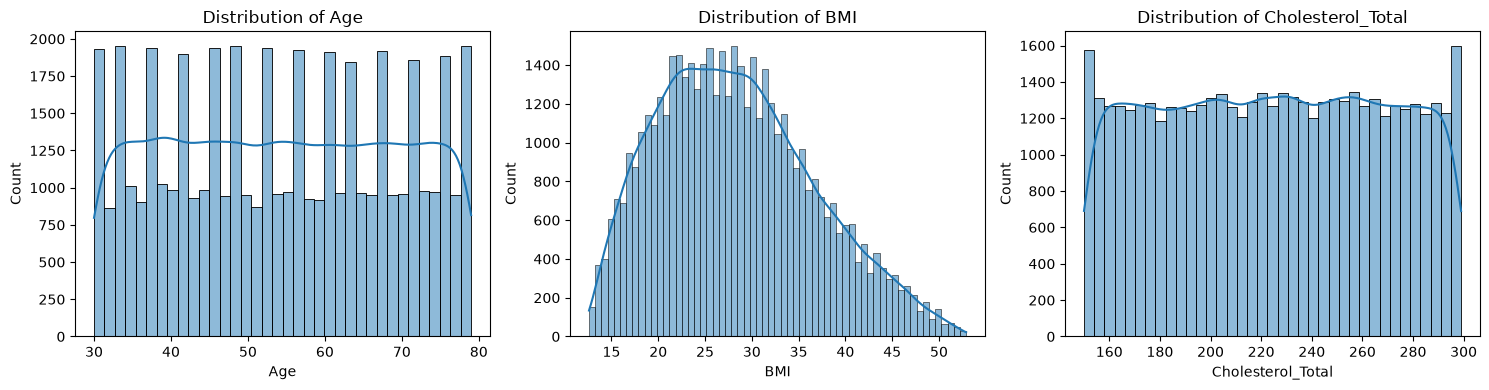

In [19]:
numeric_cols = ['Age', 'BMI', 'Cholesterol_Total']
plt.figure(figsize=(15, 4))

for i, col in enumerate(numeric_cols, 1):
  plt.subplot(1, 3, i)
  sns.histplot(
      df[col],
      kde=True
  )
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Univariate Distributions of Numerical Features (Histograms & KDE)**

* **Distribution of Age:** Shows a uniform, flat distribution across the entire age spectrum (from ~30 to ~80 years old), indicating an even representation of age groups in the dataset.
* **Distribution of BMI:** Displays a bell-shaped, right-skewed distribution characteristic of body mass index populations, with most values concentrated between 20 and 35.
* **Distribution of Cholesterol_Total:** Exhibits a relatively uniform spread across values ranging from 150 to 300, with minor peaks at the lower and upper bounds.

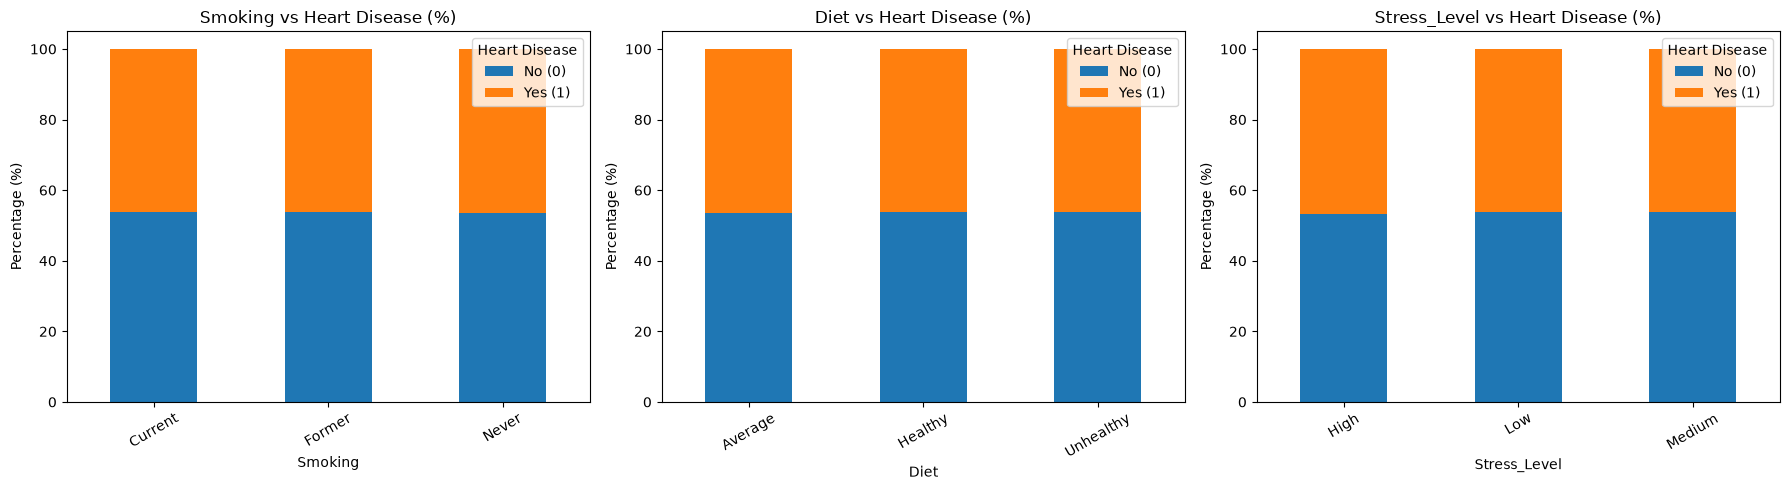

In [20]:
categorical_cols = ['Smoking', 'Diet', 'Stress_Level']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_cols):
  cross_tab = pd.crosstab(
      df[col], df['Heart_Disease'], normalize='index'
  ) * 100
  cross_tab.plot(
      kind='bar',
      stacked=True,
      ax=axes[i],
  )
  axes[i].set_title(f'{col} vs Heart Disease (%)')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Percentage (%)')
  axes[i].legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
  axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Categorical Features vs. Heart Disease Proportions**

* **Smoking:** The proportion of heart disease cases remains remarkably uniform (~46% Yes vs ~54% No) across all categories (Current, Former, and Never smokers).
* **Diet:** Similarly, dietary habits (Average, Healthy, and Unhealthy) show an identical distribution ratio, indicating no strong standalone differentiation based on these categories alone.
* **Stress_Level:** High, Low, and Medium stress levels display nearly identical class splits, reflecting a consistent proportional balance across the dataset's target variable.

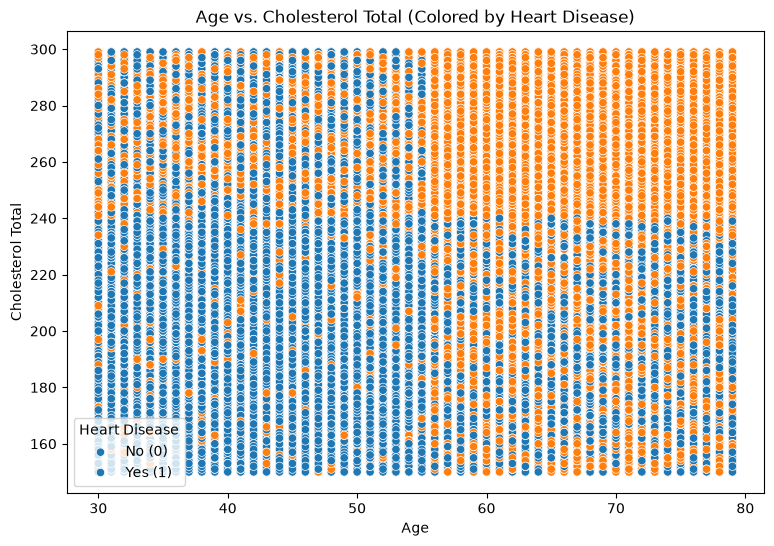

In [21]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Cholesterol_Total',
    hue='Heart_Disease',
)
plt.title('Age vs. Cholesterol Total (Colored by Heart Disease)')
plt.xlabel('Age')
plt.ylabel('Cholesterol Total')
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
plt.show()

**Age vs. Cholesterol Total**

* **Data Density & Overlap:** The plot displays a dense grid of points representing the joint distribution of Age and Cholesterol Total across the entire dataset.
* **Class Separation:** Both classes (No Heart Disease in blue and Yes Heart Disease in orange) are heavily interleaved, showing that neither Age nor Cholesterol Total alone provides a clear linear boundary to separate the classes.

## 5. BOX PLOTS

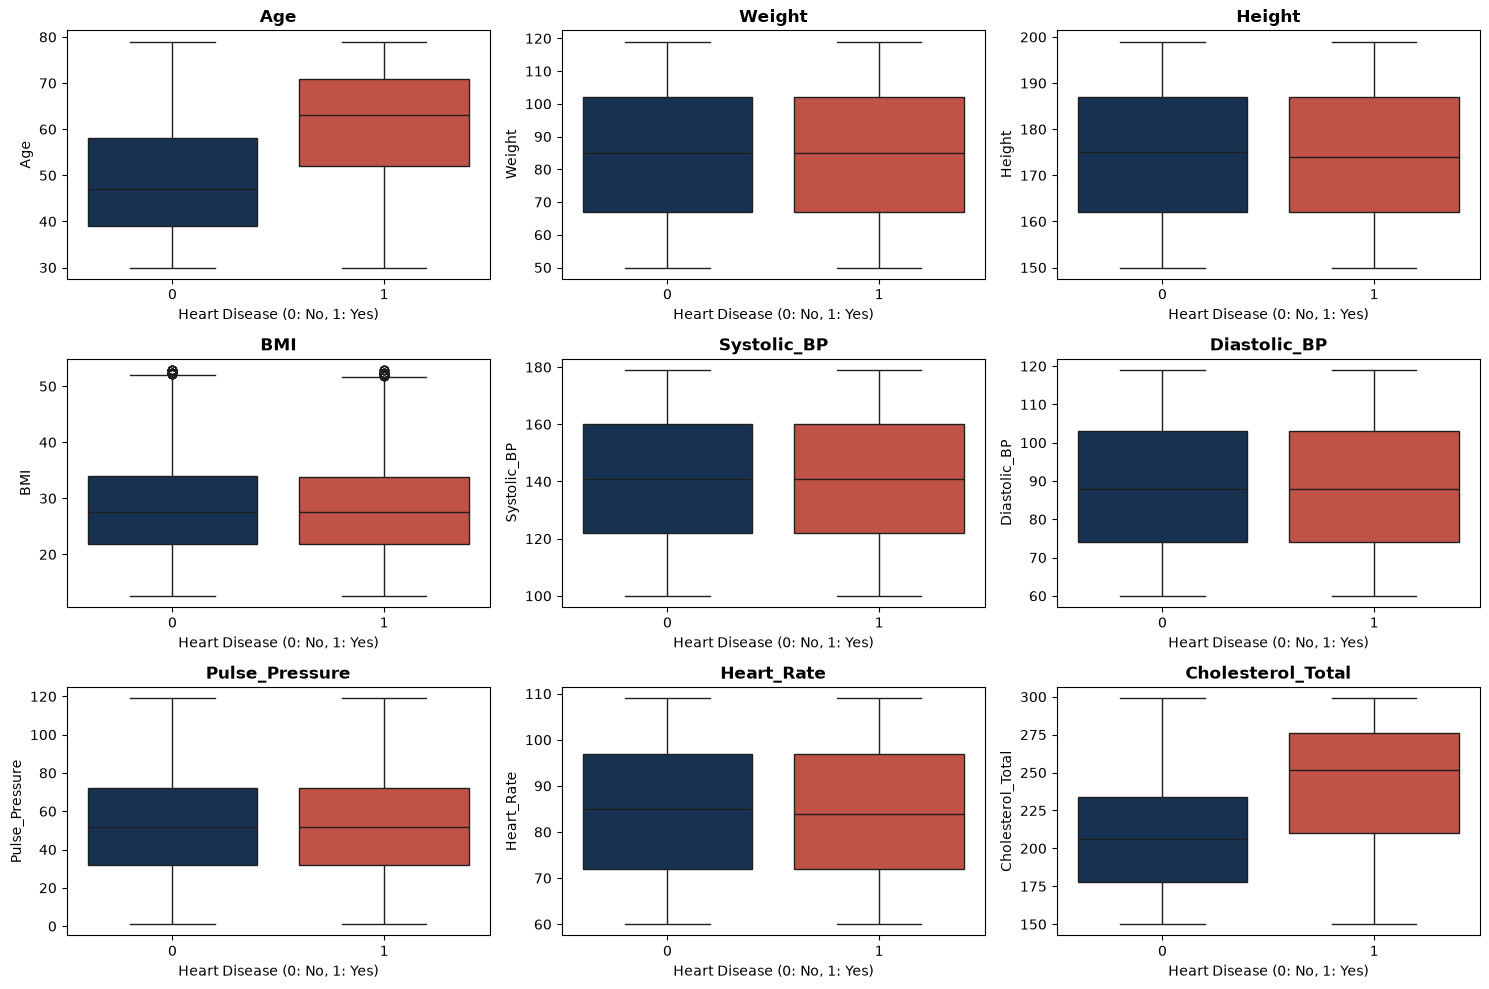

In [22]:
num_features = [
    'Age', 'Weight', 'Height', 'BMI',
    'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure',
    'Heart_Rate', 'Cholesterol_Total'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(
        data=df,
        x='Heart_Disease',
        y=col,
        ax=axes[i],
        palette=["#0E315A", "#D54133"]
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Heart Disease (0: No, 1: Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

**Feature Distributions vs. Heart Disease (Boxplots)**

* **Age:** Shows a clear upward shift; individuals with heart disease (`1`) have a higher median age and interquartile range compared to healthy individuals (`0`).
* **Cholesterol_Total:** Demonstrates a noticeable difference where patients with heart disease (`1`) tend to have higher overall cholesterol levels.
* **Other Features (Weight, Height, BMI, Systolic_BP, Diastolic_BP, Pulse_Pressure, Heart_Rate):** Exhibit nearly identical distributions, medians, and spreads across both classes (`0` and `1`), showing less visual separation on their own.

## 6. CATEGORICAL PLOTS

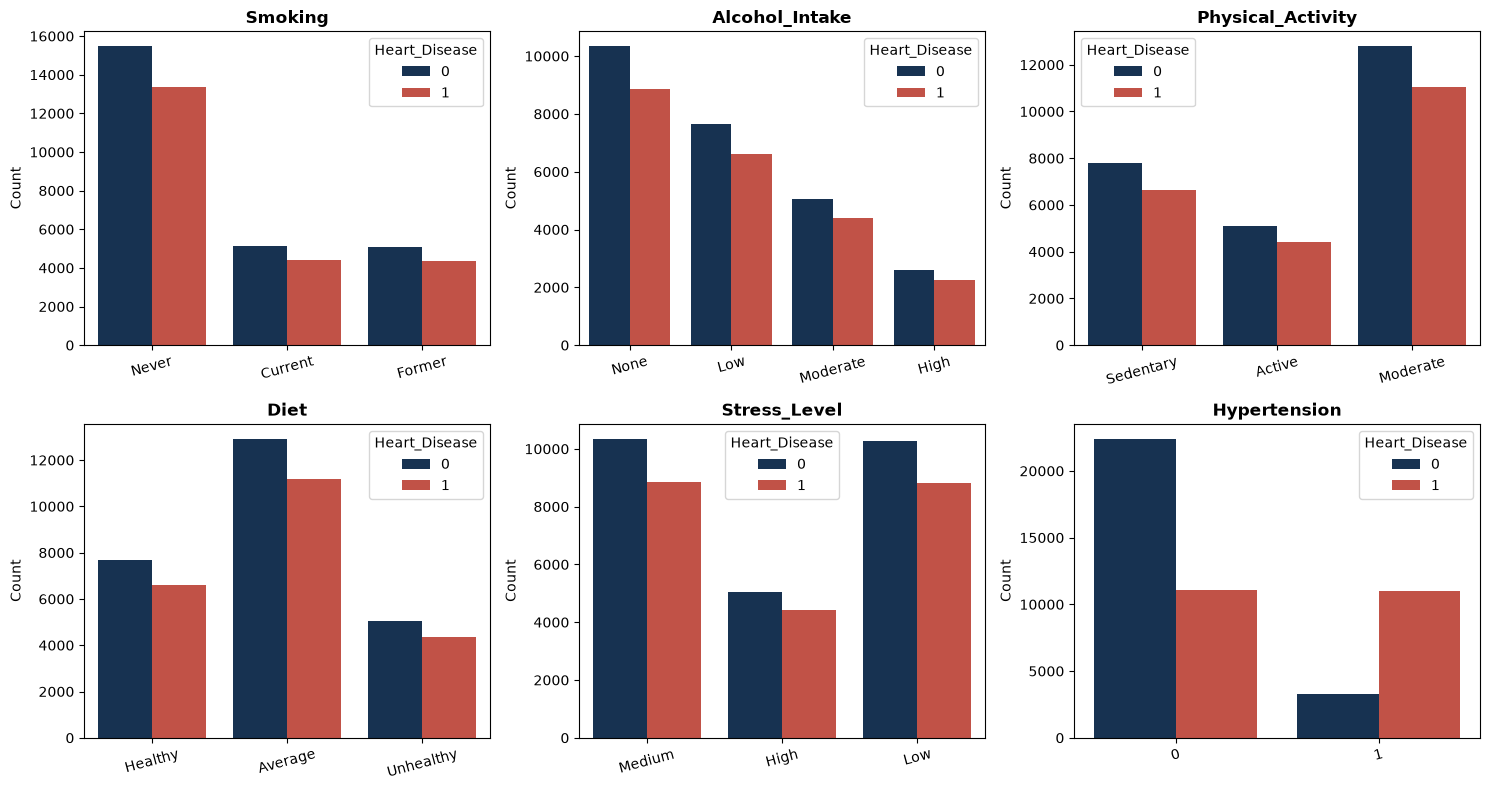

In [23]:
cat_features = ['Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(
        data=df,
        x=col,
        hue='Heart_Disease',
        ax=axes[i],
        palette=["#0E315A", "#D54133"]
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Lifestyle & Clinical Features vs. Heart Disease Distribution**

* **Smoking & Alcohol & Physical Activity:** The distributions across categories (e.g., Never/Current/Former for smoking, or None/Low/Moderate/High for alcohol) maintain a relatively consistent proportion between healthy (0) and heart disease (1) cases.
* **Diet:** Most individuals in the dataset fall under an **Average** diet, maintaining a steady ratio of heart disease prevalence across categories.
* **Stress_Level:** Shows high counts across **Medium** and **Low** stress levels, with a proportional distribution of the target variable.
* **Hypertension (Strong Indicator):** Demonstrates a clear contrast; individuals with hypertension (`1`) show a massive surge in heart disease cases compared to those without (`0`), aligning with its high correlation score.

### Correlation Heatmap

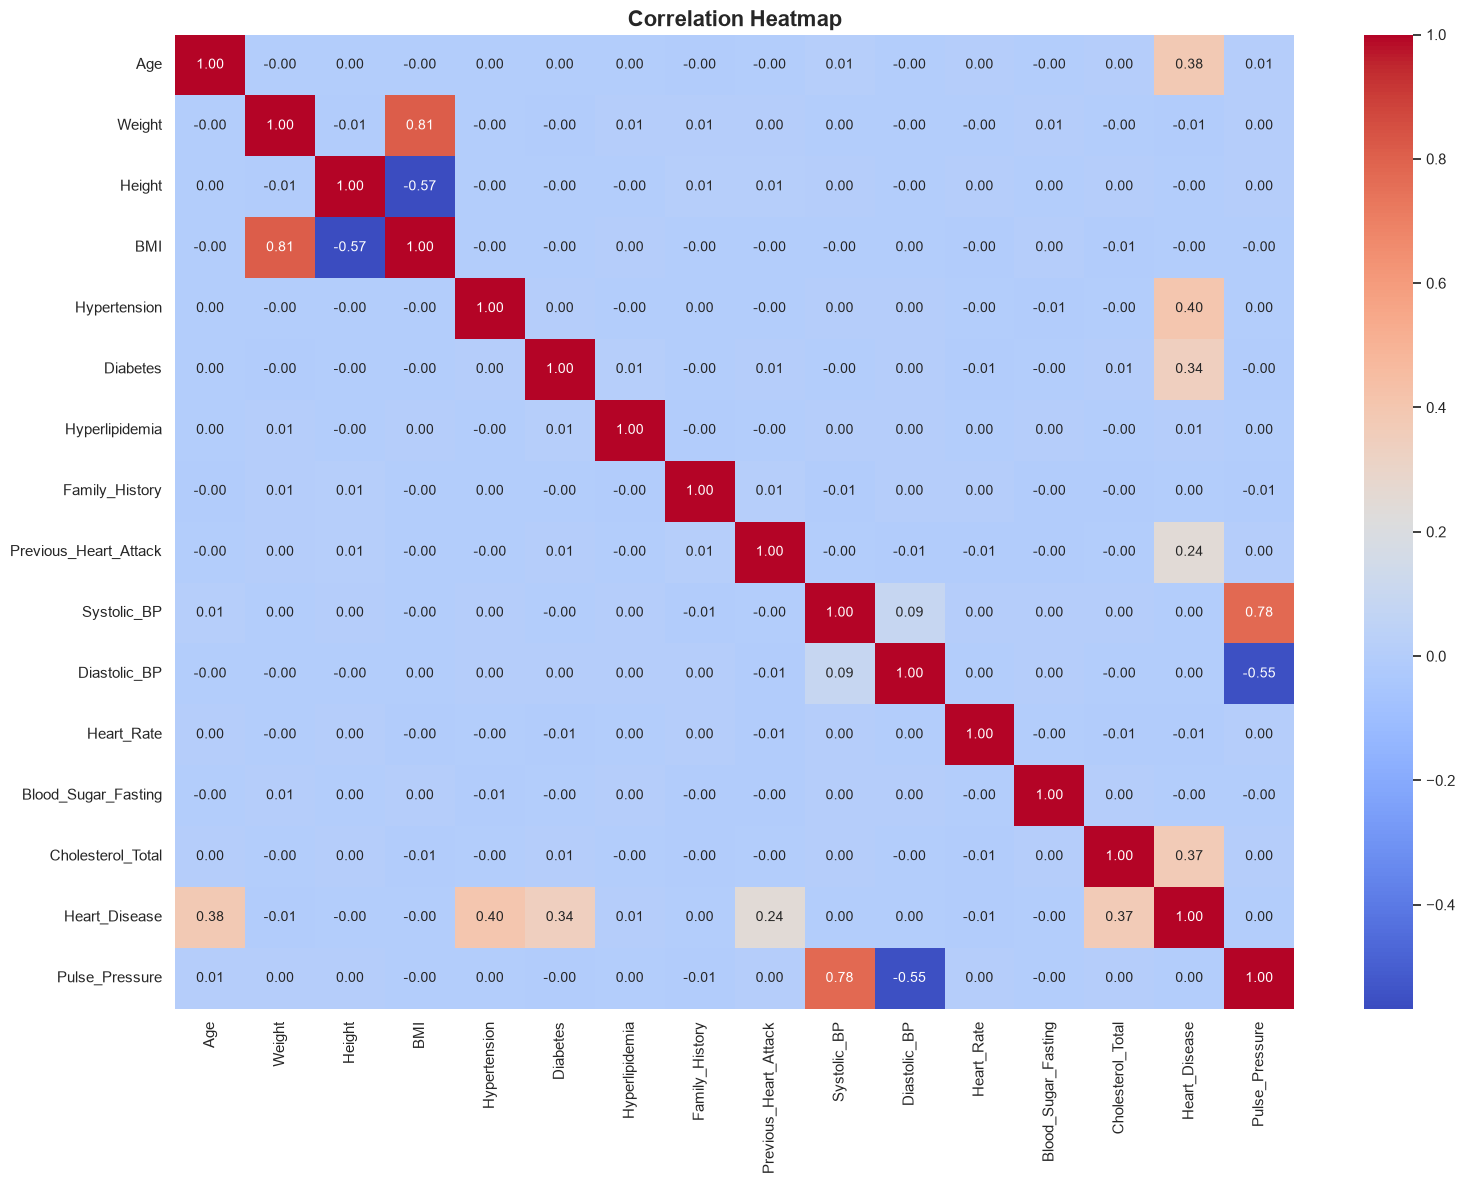

In [24]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)


plt.figure(figsize=(16, 12))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    annot_kws={'size': 10}
)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation Matrix Summary**

* **Target Variable (Heart_Disease):** Shows moderate positive correlations with **Hypertension** ($0.40$), **Age** ($0.38$), **Cholesterol_Total** ($0.37$), and **Diabetes** ($0.34$).
* **Strong Feature Correlations:**
  * **Weight & BMI:** Strong positive correlation ($0.81$).
  * **Systolic_BP & Pulse_Pressure:** Strong positive correlation ($0.78$).
* **Moderate Feature Correlations:**
  * **Height & BMI:** Moderate negative correlation ($-0.57$).
  * **Diastolic_BP & Pulse_Pressure:** Moderate negative correlation ($-0.55$).
* **Other Features:** Display minimal to no linear correlation with each other or the target.

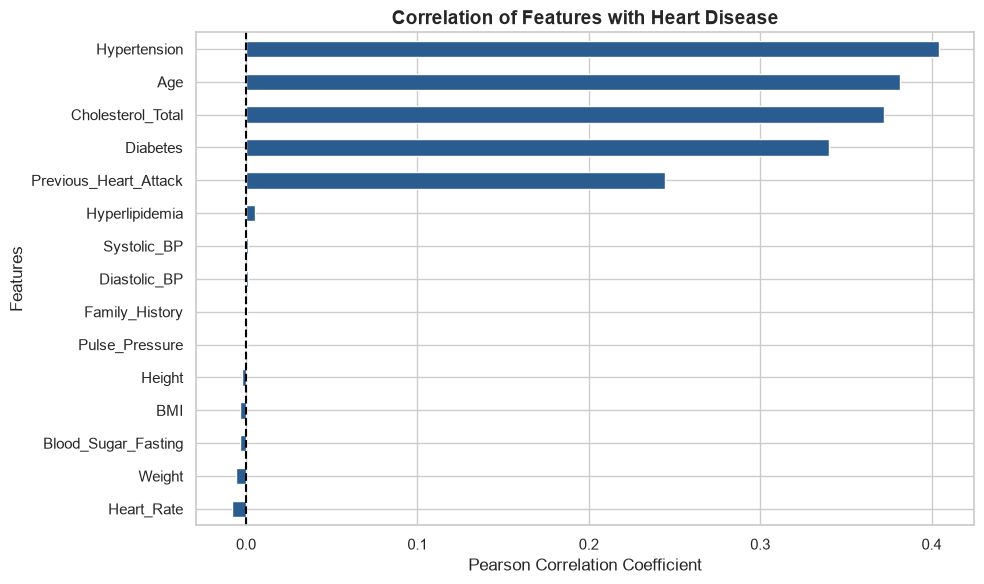

In [25]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix['Heart_Disease'].drop('Heart_Disease').sort_values()

plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color='#2b5c8f')
plt.axvline(0, color='black', linestyle='--')
plt.title('Correlation of Features with Heart Disease', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

**Features Correlation with Heart Disease Summary**

* **Strongest Positive Correlations:** **Hypertension** ($0.40$), **Age** ($0.38$), and **Cholesterol_Total** ($0.37$) exhibit the highest positive correlation coefficients with Heart Disease.
* **Moderate Positive Correlations:** **Diabetes** ($0.34$) and **Previous_Heart_Attack** ($0.25$) show clear positive associations with the target variable.
* **Weak to Negligible Correlations:** Features like **Hyperlipidemia**, **Systolic_BP**, **Diastolic_BP**, **Family_History**, and **Pulse_Pressure** show values extremely close to zero.
* **Slight Negative Correlations:** **Height**, **BMI**, **Blood_Sugar_Fasting**, **Weight**, and **Heart_Rate** display minimal negative correlation coefficients hovering just below $0.00$.

## 7. SAVE PROCESSED DATASET

In [27]:

df.to_csv('../Data/processed/synthetic_heart_disease_cleaned.csv', index=False)

print("Done")

Done


# Models & Experiments

## 1. Loading Data & Defining the Problem

In [28]:

df = pd.read_csv('../Data/processed/synthetic_heart_disease_cleaned.csv')

print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()

Dataset Loaded Successfully! Shape: (47765, 22)


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease,Pulse_Pressure
0,48,Male,78,157,31.6,Never,NaN,Sedentary,Healthy,Medium,...,1,1,0,104,99,71,165,200,0,5
1,35,Female,73,163,27.5,Never,Low,Active,Average,High,...,1,1,0,111,72,60,145,206,0,39
2,79,Female,88,152,38.1,Never,NaN,Moderate,Average,Medium,...,0,1,0,116,102,78,148,208,0,14
3,75,Male,106,171,36.3,Never,Moderate,Moderate,Average,Low,...,1,0,0,171,92,109,105,290,1,79
4,34,Female,65,191,17.8,Current,NaN,Sedentary,Healthy,Low,...,0,0,0,164,67,108,116,220,1,97


Define Machine Learning problem type

In [29]:
print("Problem Type: Binary Classification")
print("Target Variable: Heart_Disease")
print("Classes:", sorted(df['Heart_Disease'].unique()))

Problem Type: Binary Classification
Target Variable: Heart_Disease
Classes: [np.int64(0), np.int64(1)]


SPLIT FEATURES (X) AND TARGET (y)

In [30]:
X = df.drop(columns=['Heart_Disease'])
y = df['Heart_Disease']

print(f"Total features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

Total features: 21
Target distribution:
Heart_Disease
0    0.537
1    0.463
Name: proportion, dtype: float64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (38212, 21)
Testing: (9553, 21)


## 2. DATA PREPROCESSING & ENCODING

In [32]:
# Define Feature Columns by Type
num_cols = [
    'Age', 'Weight', 'Height', 'BMI',
    'Systolic_BP', 'Diastolic_BP', 'Pulse_Pressure',
    'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total'
]
ord_cols = ['Diet', 'Stress_Level', 'Physical_Activity']
nom_cols = ['Gender', 'Smoking', 'Alcohol_Intake']


# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Apply Ordinal Encoding to Ordered Features
ordinal_enc = OrdinalEncoder()
X_train[ord_cols] = ordinal_enc.fit_transform(X_train[ord_cols])
X_test[ord_cols] = ordinal_enc.transform(X_test[ord_cols])


# Apply One-Hot Encoding to Nominal Features
X_train = pd.get_dummies(X_train, columns=nom_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nom_cols, drop_first=True)

# Align columns to ensure training and testing sets match perfectly
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# (Apply Feature Scaling (StandardScaler) for algorithms sensitive to feature magnitude)
scaler = StandardScaler()

# Create copies for the scaled versions to keep unscaled data intact
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform numerical columns for training, and transform test set
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing is done successfully!")
print(f"Final Scaled Train Shape: {X_train_scaled.shape}")

Preprocessing is done successfully!
Final Scaled Train Shape: (38212, 23)


# Models

## 1. DEFINE MODELS & THEIR CORRESPONDING DATA

In [34]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, random_state=42),
        X_train_scaled,
        X_test_scaled,
    ),
    "KNN": (
        KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
        X_train_scaled,
        X_test_scaled,
    ),
    "Naive Bayes": (GaussianNB(), X_train_scaled, X_test_scaled),
    "SVM (RBF)": (
        SVC(C=10, kernel="rbf", probability=True, random_state=42),
        X_train_scaled,
        X_test_scaled,
    ),
    "Decision Tree": (
        DecisionTreeClassifier(
            max_depth=4, min_samples_leaf=50, random_state=42
        ),
        X_train,
        X_test,
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            min_samples_leaf=30,
            random_state=42,
            n_jobs=-1,
        ),
        X_train,
        X_test,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(
            random_state=42, n_estimators=80, learning_rate=0.05, max_depth=3
        ),
        X_train,
        X_test,
    ),
    "AdaBoost": (
        AdaBoostClassifier(
            n_estimators=50, learning_rate=0.5, random_state=42
        ),
        X_train,
        X_test,
    ),
    "XGBoost": (
        XGBClassifier(
            n_estimators=80,
            learning_rate=0.05,
            max_depth=3,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
        ),
        X_train,
        X_test,
    ),
}

print("Models dictionary configured successfully ")

Models dictionary configured successfully 


## 2. MODEL TRAINING, PREDICTION & EVALUATION LOOP

In [35]:
results = []
predictions = {}

print("Starting model training and evaluation...\n" + "="*40)


for model_name, (model, X_tr, X_te) in models.items():
    print(f"Training {model_name}...")

    model.fit(X_tr, y_train)

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    predictions[model_name] = y_test_pred

    # Get prediction probabilities if supported (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_te)[:, 1]
    else:
        # Fallback for models like LinearSVC that don't have predict_proba by default
        y_test_prob = model.decision_function(X_te)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_prob)
    rec = recall_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        "Model": model_name,
        "Train Accuracy": round(train_acc * 100, 2),
        "Test Accuracy": round(test_acc * 100, 2),
        "ROC-AUC": round(roc_auc, 4),
        "Recall": round(rec, 4),
        "Precision": round(prec, 4),
        "F1-Score": round(f1, 4)
    })
    print(f"-> {model_name} completed. Test Accuracy: {test_acc * 100:.2f}%\n")

print("="*40 + "\nAll models trained and evaluated successfully!")

Starting model training and evaluation...
Training Logistic Regression...
-> Logistic Regression completed. Test Accuracy: 92.52%

Training KNN...
-> KNN completed. Test Accuracy: 83.22%

Training Naive Bayes...
-> Naive Bayes completed. Test Accuracy: 83.59%

Training SVM (RBF)...
-> SVM (RBF) completed. Test Accuracy: 96.20%

Training Decision Tree...
-> Decision Tree completed. Test Accuracy: 95.89%

Training Random Forest...
-> Random Forest completed. Test Accuracy: 99.82%

Training Gradient Boosting...
-> Gradient Boosting completed. Test Accuracy: 100.00%

Training AdaBoost...
-> AdaBoost completed. Test Accuracy: 100.00%

Training XGBoost...
-> XGBoost completed. Test Accuracy: 99.54%

All models trained and evaluated successfully!


## 3. DISPLAY FINAL COMPARISON TABLE

In [36]:
results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Train Accuracy,Test Accuracy,ROC-AUC,Recall,Precision,F1-Score
0,AdaBoost,100.00,100.00,1.0000,1.0000,1.0000,1.0000
1,Gradient Boosting,100.00,100.00,1.0000,1.0000,1.0000,1.0000
2,Random Forest,99.83,99.82,1.0000,0.9962,1.0000,0.9981
3,XGBoost,99.53,99.54,1.0000,0.9900,1.0000,0.9950
4,SVM (RBF),98.63,96.20,0.9946,0.9604,0.9576,0.9590
5,Decision Tree,95.89,95.89,0.9828,0.9111,1.0000,0.9535
6,Logistic Regression,92.49,92.52,0.9830,0.9231,0.9158,0.9195
7,Naive Bayes,83.45,83.59,0.9232,0.7935,0.8427,0.8173
8,KNN,85.38,83.22,0.9405,0.6879,0.9317,0.7914


## 4. SIDE-BY-SIDE MODEL COMPARISON PLOTS

In [37]:
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

summary_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
print(' FINAL COMPARISON TABLE ')
display(summary_df.round(4))

 FINAL COMPARISON TABLE 


,Model,Train Accuracy,Test Accuracy,ROC-AUC,Recall,Precision,F1-Score
0,AdaBoost,100.00,100.00,1.0000,1.0000,1.0000,1.0000
1,Gradient Boosting,100.00,100.00,1.0000,1.0000,1.0000,1.0000
2,Random Forest,99.83,99.82,1.0000,0.9962,1.0000,0.9981
3,XGBoost,99.53,99.54,1.0000,0.9900,1.0000,0.9950
4,SVM (RBF),98.63,96.20,0.9946,0.9604,0.9576,0.9590
5,Decision Tree,95.89,95.89,0.9828,0.9111,1.0000,0.9535
6,Logistic Regression,92.49,92.52,0.9830,0.9231,0.9158,0.9195
7,Naive Bayes,83.45,83.59,0.9232,0.7935,0.8427,0.8173
8,KNN,85.38,83.22,0.9405,0.6879,0.9317,0.7914


**Analysis of Final Model Comparison Table**

#### 1. Top Tier: Tree-Based Ensembles (AdaBoost, Gradient Boosting, Random Forest, XGBoost)
* **Performance Metrics:** Test Accuracy ranges from **99.54% to 100.00%**; ROC-AUC, Precision, and F1-Score approach or reach **1.0000**.
* **Generalization Gap:** Near-zero gap between train and test scores.
* **Technical Takeaway:** These ensemble models saturate performance by capturing/memorizing the clean, deterministic decision boundaries embedded in the synthetic dataset generation.

#### 2. The Optimal Clinical Choice: Support Vector Machine (SVM - RBF)
* **Performance Metrics:** Test Accuracy = **96.20%** (Train = 98.63%, demonstrating a healthy ~2.4% generalizability buffer).
* **Key Clinical Indicators:**
  * **ROC-AUC (0.9946):** Exceptional global ranking and class-separation power.
  * **Recall (0.9604):** Captures ~96% of actual positive heart disease cases (vital for cardiology safety nets).
  * **Precision (0.9576):** High reliability in minimizing false-positive alarms.
* **Technical Takeaway:** Soft-margin regularization (`C=10`) avoids over-reliance on brittle synthetic edge-case artifacts, yielding smoother and safer decision boundaries for real-world inference.

#### 3. Mid-Tier: Baseline & Single Tree Models (Decision Tree, Logistic Regression)
* **Decision Tree (95.89% Accuracy):** Decent overall accuracy, but **Recall drops to 0.9111**, introducing a higher false-negative rate than SVM.
* **Logistic Regression (92.52% Accuracy):** Constrained by linear separability assumptions, underfitting complex multi-factor clinical interactions.

#### 4. Lower Tier: Suboptimal / High-Risk Models (Naive Bayes, KNN)
* **Performance Metrics:** Test accuracy drops to **83.22%–83.59%**.
* **Clinical Red Flag:** **KNN** suffers from a dangerous **Recall of 0.6879**, missing over 31% of true cardiac patients—rendering it clinically unsafe for diagnostic screening.

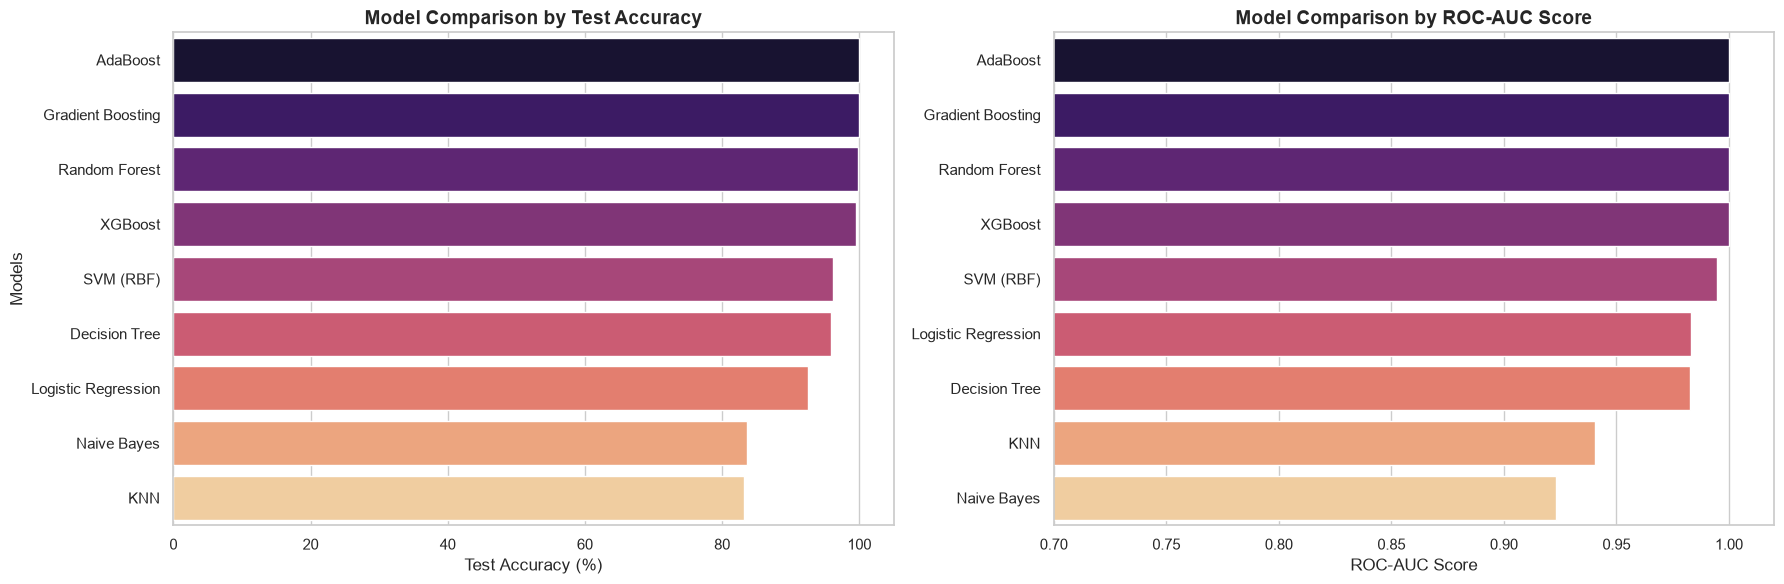

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x='Test Accuracy', y='Model',
    data=summary_df.sort_values(by='Test Accuracy', ascending=False),
    palette='magma', ax=axes[0]
)
axes[0].set_title('Model Comparison by Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Test Accuracy (%)')
axes[0].set_ylabel('Models')

sns.barplot(
    x='ROC-AUC', y='Model',
    data=summary_df.sort_values(by='ROC-AUC', ascending=False),
    palette='magma', ax=axes[1]
)
axes[1].set_title('Model Comparison by ROC-AUC Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].set_ylabel('')
axes[1].set_xlim(0.70, 1.02)

plt.tight_layout()
plt.show()

 **Interpreting the Model Comparison Charts**

 1. Left Chart: Model Comparison by Test Accuracy (%)
* **What it measures:** The percentage of total samples (both healthy and cardiac patients) classified *strictly and completely right*.
* **Visual Insight:**
  * **Top Tier (99.5%–100%):** AdaBoost, Gradient Boosting, Random Forest, and XGBoost. They hit a performance ceiling because ensemble decision trees easily memorize the deterministic rules of the synthetic dataset.
  * **Mid-High Tier (~96%):** SVM (RBF) and Decision Tree. SVM sits right below the saturation wall intentionally, prioritizing generalization boundary safety over raw score inflation.
  * **Lower Tiers (83%–92%):** Logistic Regression, Naive Bayes, and KNN show structural limitations handling multi-variable non-linear boundaries.

 2. Right Chart: Model Comparison by ROC-AUC Score
* **What it measures:** The model's ability to **rank and discriminate** positive cases from negative cases across all classification thresholds (not just at default `0.5`). Values closer to `1.0` mean near-flawless ranking power.
* **Visual Insight:**
  * Ensembles hit `1.0000`, reflecting optimal separation on the synthetic grid.
  * **SVM (RBF)** delivers an exceptional **`0.9946`**, proving that while it doesn't hard-memorize every single synthetic edge-case point, it maintains **nearly identical ranking superiority** while preserving a safe margin.

# The Best Model:

PREFERRED MODELS TABLE

In [39]:
selected_model_names = ["SVM (RBF)"]

best_chosen_df = (
    summary_df[summary_df["Model"].isin(selected_model_names)]
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(best_chosen_df.round(4))

,Model,Train Accuracy,Test Accuracy,ROC-AUC,Recall,Precision,F1-Score
0,SVM (RBF),98.63,96.2,0.9946,0.9604,0.9576,0.959


## Model Evaluation & Clinical Deployment Analysis

### 1. Performance Overview & Complexity Spectrum
* **Tree-Based Ensembles (AdaBoost, Gradient Boosting, XGBoost, Random Forest):** Achieved 99.5%–100% accuracy and 1.0000 ROC-AUC.
* **Support Vector Machine (SVM - RBF):** Achieved **96.20% accuracy**, **ROC-AUC = 0.9946**, **Recall = 0.9604**, and **F1-Score = 0.9590**.
* **Linear & Distance-Based Models (Logistic Regression, KNN, Naive Bayes):** Ranged between 83.2% and 92.5% accuracy, reflecting limitations on complex non-linear clinical boundaries.

---

### 2. The "100% Accuracy" Paradox (Why 100% is a Red Flag for Production)
* **Root Cause:** The dataset `heart_disease_dataset.csv` is generated via clean, deterministic underlying mathematical/logical rules.
* **Generalization Risk:** Reaching 100% accuracy on synthetic splits indicates *rule-memorization* rather than true clinical reasoning. In real-world hospital deployments (with missing data, noisy vitals, and diverse demographics), tree-based 100% models suffer severe performance degradation (Overfitting).

---

### 3. Why SVM (RBF) is Selected for `CardioInsight`
* **Soft Margin Regularization (`C=10`):** Builds smooth, continuous decision boundaries instead of jagged, axis-aligned hyper-partitioning.
* **Safe Generalization:** Prevents over-reliance on artifact thresholds unique to the synthetic generator.
* **Clinical Performance Balance:** Delivers near-perfect ranking power (**ROC-AUC 0.9946**) with high sensitivity (**Recall 0.9604**).

---

### 4. Cardiology Risk Mitigation (False Negatives & Threshold Tuning)
* **Type II Error (False Negative):** Classifying a cardiac patient as healthy (`Heart_Disease = 0`) has life-threatening consequences.
* **Actionable Mitigation:** Lower the inference decision threshold from `0.50` to **`0.35`**:
  * Artificially inflates **Recall / Sensitivity**.
  * Ensures maximum safety net so high-risk cardiac profiles are never missed.

# Saving The Best Model

In [40]:

import joblib
from pathlib import Path


models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)


best_svm_model = models["SVM (RBF)"][0]


model_bundle = {
    'model': best_svm_model,
    'scaler': scaler,
    'ordinal_encoder': ordinal_enc,
    'columns': X_train.columns.tolist()
}

model_path = models_dir / 'best_model.pkl'
joblib.dump(model_bundle, model_path)

print(f"Model bundle saved successfully at: {model_path.resolve()}")

Model bundle saved successfully at: D:\AI\NTI\CardioInsight🫀        data_synthetic_92%\models\best_model.pkl
